In [1]:
pth = r'/home/zzj/projects/FTSAD/supp_files/latency_real_world_j10_processed.csv'

import pandas as pd
data = pd.read_csv(pth)
print(data.shape)

(990, 8)


In [2]:
# remove model_name == 'Random'
data = data[data['model_name'] != 'Random']
print(data.shape)

(900, 8)


In [3]:
import re

case_config = r'/home/zzj/projects/FTSAD/supp_files/real_config_table_4_ipynb.csv'

case_data = pd.read_csv(case_config)

def get_seg_type(row):
    min_seg_len = row['min_seg_len']
    max_seg_len = row['max_seg_len']
    seg_type = f"{min_seg_len}-{max_seg_len}"
    return seg_type

case_data['seg_type'] = case_data.apply(get_seg_type, axis=1)



data_new = pd.merge(data, case_data, how='left', on='case_name')

# 把所有case_name 为NIPS_TS_Creditcard的名字改成Creditcard
data_new['case_name'] = data_new['case_name'].replace('NIPS_TS_Creditcard', 'Creditcard')

# 排序，按照seg_type: 先比前面的数字，然后L，H的顺序
def sort_seg_type_key(tmp):
    idx = tmp[:-1]    
    typ = tmp[-1]
    return (int(idx), 0 if typ == 'L' else 1)

seg_type_key_list = [
    
]

metric_sort = [
  "F1",
  "F1-PA",
  "Reduced-F1",
  "PA%K",
  "R-based F1",
  "TaPR",
  "eTaPR",
  "Aff-F1",
  "NAff-F1",
  "UAff-F1",
  "PATE",
  "AUC-ROC",
  "AUC-PR",
  "VUS-ROC",
  "VUS-PR"
]

def sort_metric_key(tmp):
    idx = metric_sort.index(tmp)
    return idx
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm

print(data_new.head())
print(data_new.columns)

  case_name model_name  case_seed metric_name  mean_val   std_val  \
0       MSL    Model10         42      AUC-PR  0.057350  0.000155   
1       MSL    Model10         42     AUC-ROC  0.099658  0.002740   
2       MSL    Model10         42      Aff-F1  0.613145  0.012296   
3       MSL    Model10         42          F1  0.008382  0.001684   
4       MSL    Model10         42       F1-PA  0.687022  0.045130   

   mean_latency  std_latency  ts_len  seg  max_seg_len  min_seg_len  \
0     11.210488     0.223674   73729   36         1141           11   
1     32.851632     1.189306   73729   36         1141           11   
2    389.613009     9.101273   73729   36         1141           11   
3     13.702560     0.218918   73729   36         1141           11   
4     40.736163     0.780118   73729   36         1141           11   

   avg_seg_len seg_type  
0   215.722222  11-1141  
1   215.722222  11-1141  
2   215.722222  11-1141  
3   215.722222  11-1141  
4   215.722222  11-1141  
In

(900, 14)
Empty DataFrame
Columns: [Metric, Avg. Latency, Std. Latency, Avg. Latency per point]
Index: []


/tmp/ipykernel_3928929/748794224.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom_palette = cm.get_cmap('tab10').colors[:len(seg_type_key_list)]


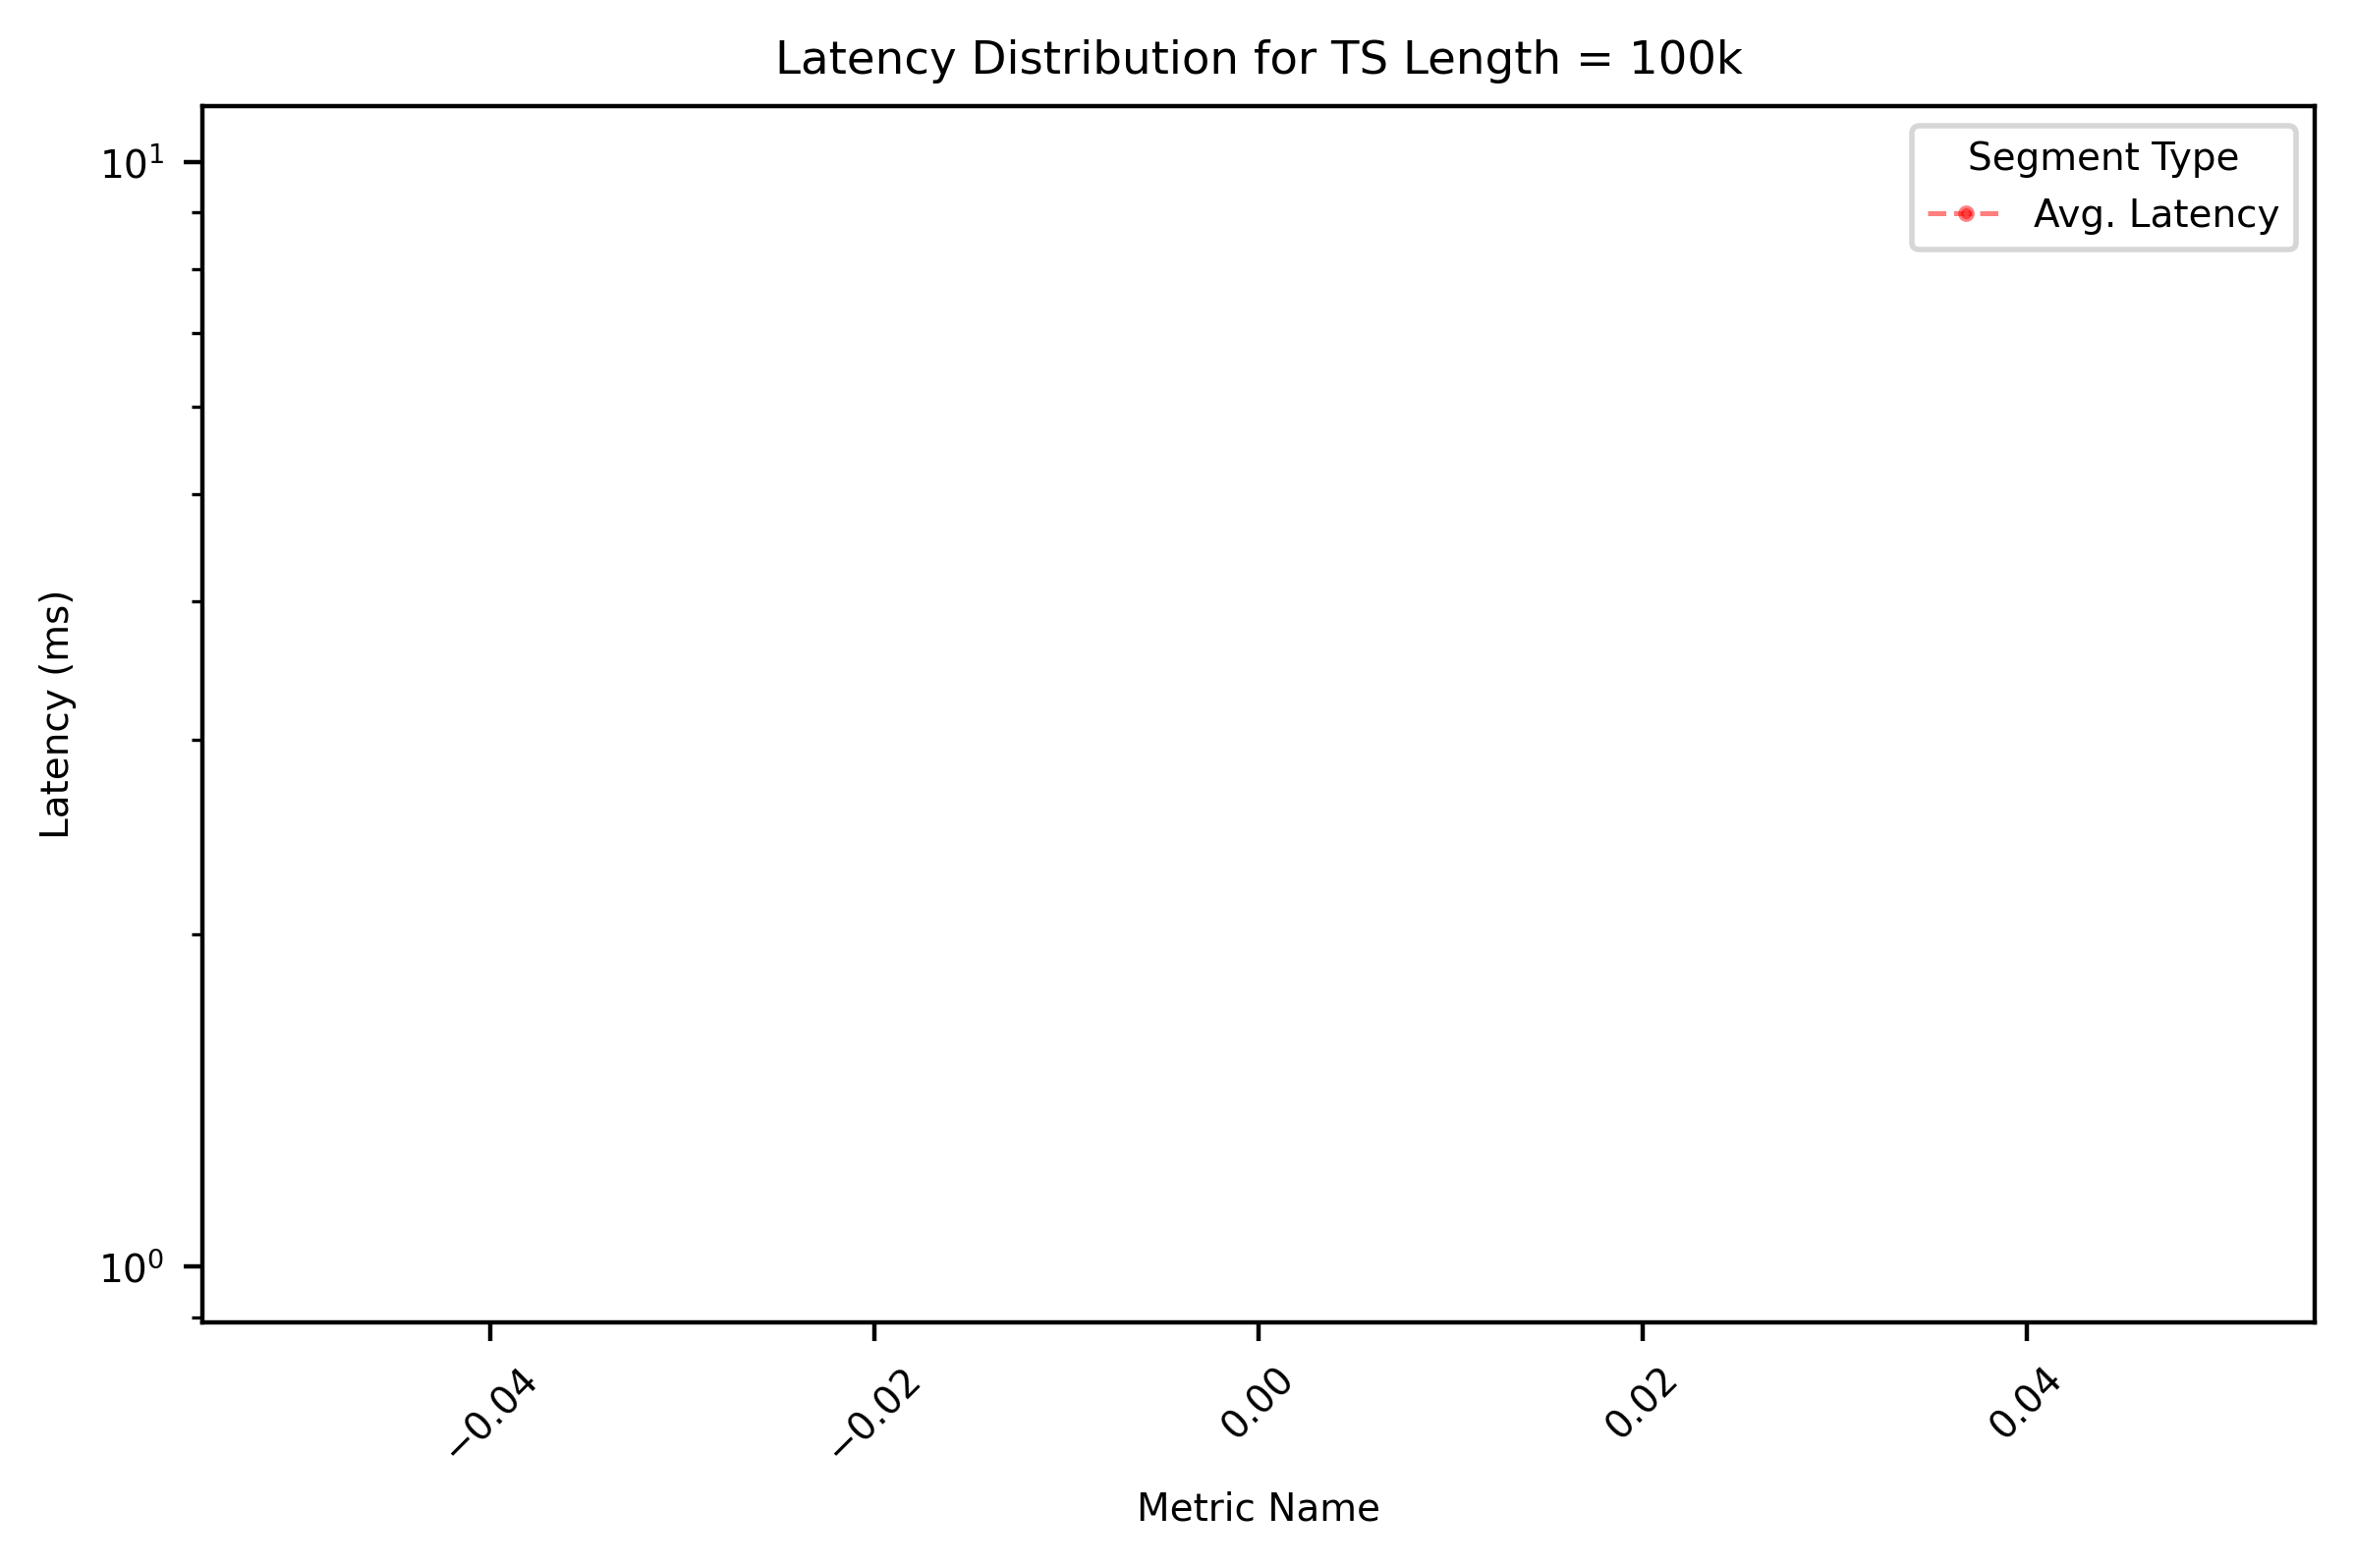

/tmp/ipykernel_3928929/748794224.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom_palette = cm.get_cmap('tab10').colors[:len(seg_type_key_list)]


Empty DataFrame
Columns: [Metric, Avg. Latency, Std. Latency, Avg. Latency per point]
Index: []


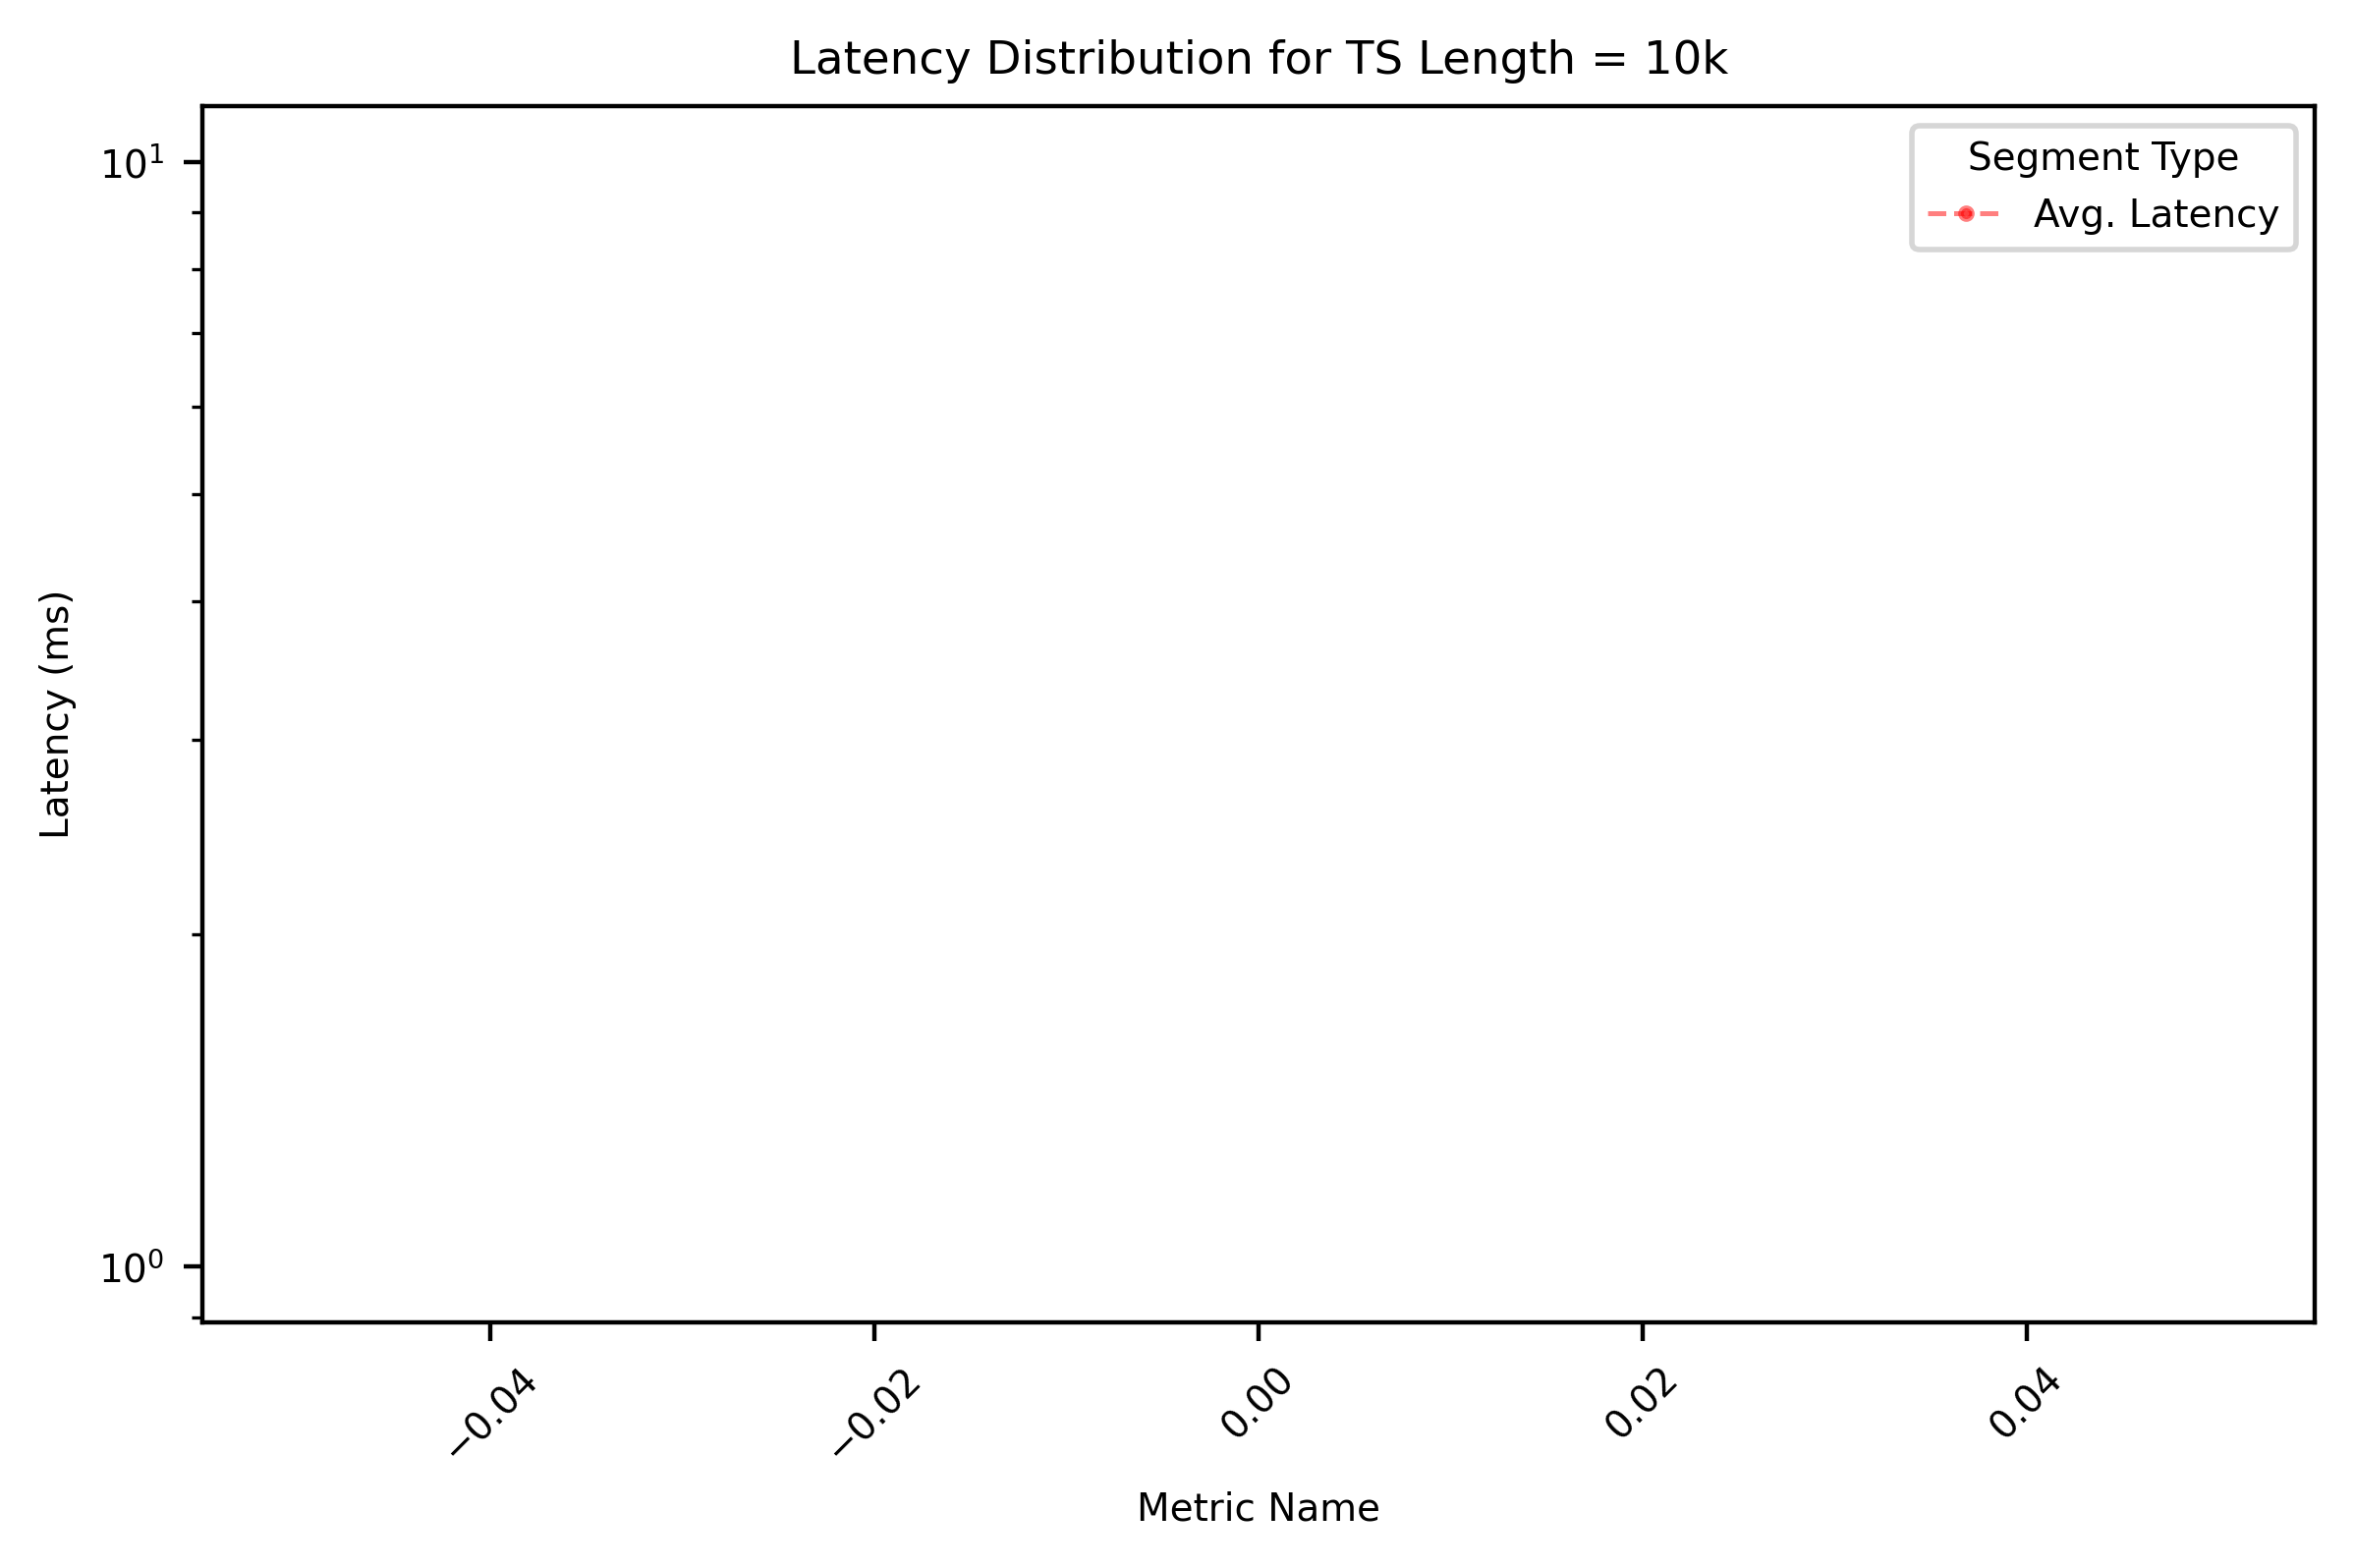

In [7]:
def plot_latency_distribution1(data_new, ts_len=100000):
    df = data_new.copy()

    df = df[df['ts_len'] == ts_len]
    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    custom_palette = cm.get_cmap('tab10').colors[:len(seg_type_key_list)]
    plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df, 
                order=metric_sort, 
                hue='seg_type', 
                hue_order=seg_type_key_list,
                showfliers=False,
                # 线粗
                linewidth=0.5,
                palette=custom_palette)
    # 计算每个分组的平均值
    mean_values = df.groupby('metric_name')['mean_latency'].mean().reset_index()
    std_values = df.groupby('metric_name')['mean_latency'].std().reset_index()
    mean_values = mean_values.sort_values(by='metric_name', key=lambda x: x.apply(sort_metric_key))
    std_values = std_values.sort_values(by='metric_name', key=lambda x: x.apply(sort_metric_key))

    out_pth = f'/home/zzj/projects/FTSAD/supp_files/avg_latency_{ts_len}_real.csv'
    # 转置
    saving_df = pd.merge(mean_values, std_values, on='metric_name', suffixes=('_mean', '_std'))
    saving_df.columns = ['Metric', 'Avg. Latency', 'Std. Latency']
    saving_df['Avg. Latency per point'] = saving_df['Avg. Latency'] / ts_len
    print(saving_df)
    saving_df.to_csv(out_pth, index=False)
    

    mean_values = mean_values.to_numpy()
    plt.plot(mean_values[:, 0], mean_values[:, 1], color='red', marker='o', markersize=2, label='Avg. Latency'
             , linestyle='--', linewidth=0.9,
            #  透明度
                alpha=0.5
             )
    # 在上方显示平均值
    x_positions = np.arange(len(metric_sort))  # 获取 x 轴的位置
    
        
    plt.legend(title='Segment Type')
    tmp = '100k' if ts_len == 100000 else f'{ts_len//1000}k'
    plt.title(f'Latency Distribution for TS Length = {tmp}')
    plt.xlabel('Metric Name')
    plt.ylabel('Latency (ms)')
    plt.yscale('log', base=10)  # 设置y轴为对数坐标
    plt.xticks(rotation=45)
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/avg_latency_{ts_len}_real.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

# plot_latency_distribution1(data_new)  # Plot for ts_len = 100000
# plot_latency_distribution1(data_new,10000)  # Plot for ts_len = 100000

[(4, '4 Segs (SMD-3-1)'), (8, '8 Segs (SMD-1-1)'), (13, '13 Segs (SMD-2-1)'), (35, '35 Segs (SWAT)'), (36, '36 Segs (MSL)'), (465, '465 Segs (Creditcard)')]
[4, 8, 13, 35, 36, 465]


[<matplotlib.patches.Rectangle object at 0x7d6ea2976150>, <matplotlib.patches.Rectangle object at 0x7d6ea29761b0>, <matplotlib.patches.Rectangle object at 0x7d6ea4d8e4b0>, <matplotlib.patches.Rectangle object at 0x7d6ea2837a70>, <matplotlib.patches.Rectangle object at 0x7d6ea28b8bf0>, <matplotlib.patches.Rectangle object at 0x7d6ea2429af0>] ['4', '8', '13', '35', '36', '465']


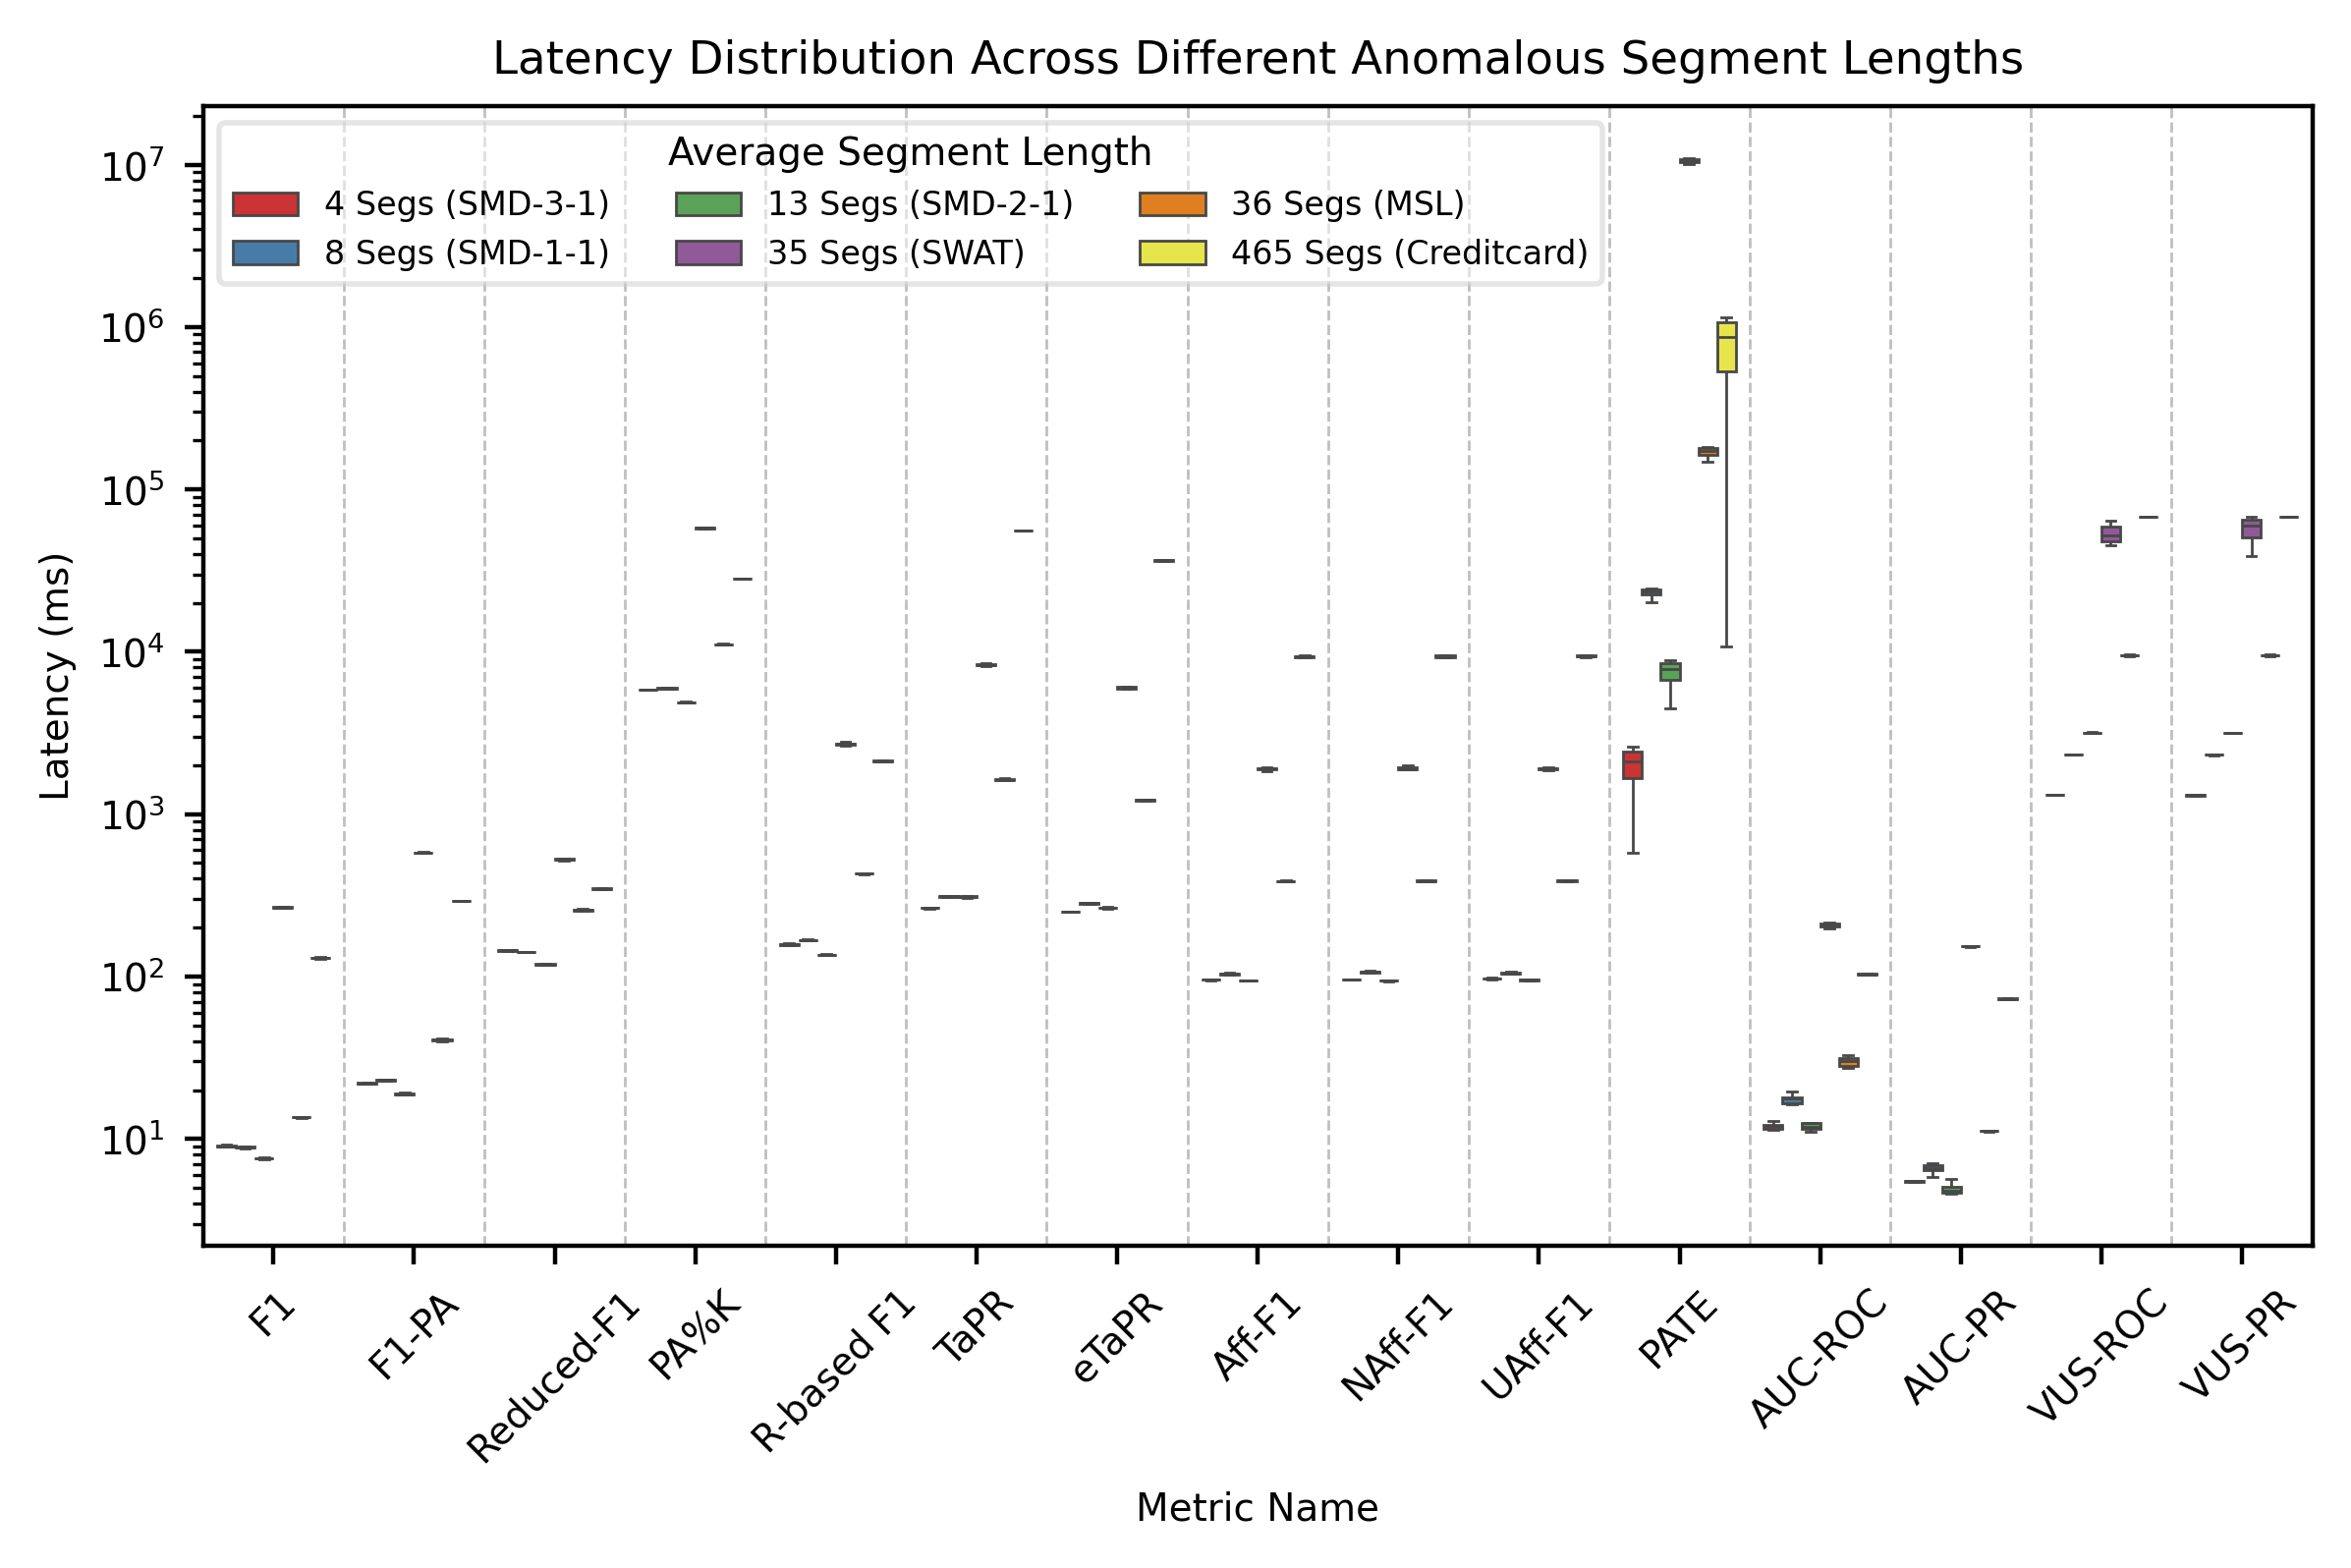

[(23694, '23694 (SMD-2-1)'), (28479, '28479 (SMD-1-1)'), (28700, '28700 (SMD-3-1)'), (73729, '73729 (MSL)'), (284807, '284807 (Creditcard)'), (449919, '449919 (SWAT)')]
[23694, 28479, 28700, 73729, 284807, 449919]
[<matplotlib.patches.Rectangle object at 0x7d6eac3e9ac0>, <matplotlib.patches.Rectangle object at 0x7d6ea23047d0>, <matplotlib.patches.Rectangle object at 0x7d6ea2943290>, <matplotlib.patches.Rectangle object at 0x7d6ea2940a40>, <matplotlib.patches.Rectangle object at 0x7d6ea4dbce90>, <matplotlib.patches.Rectangle object at 0x7d6ea1f54050>] ['11-1141', '1-5', '2-721', '8-452', '21-131', '101-35900']


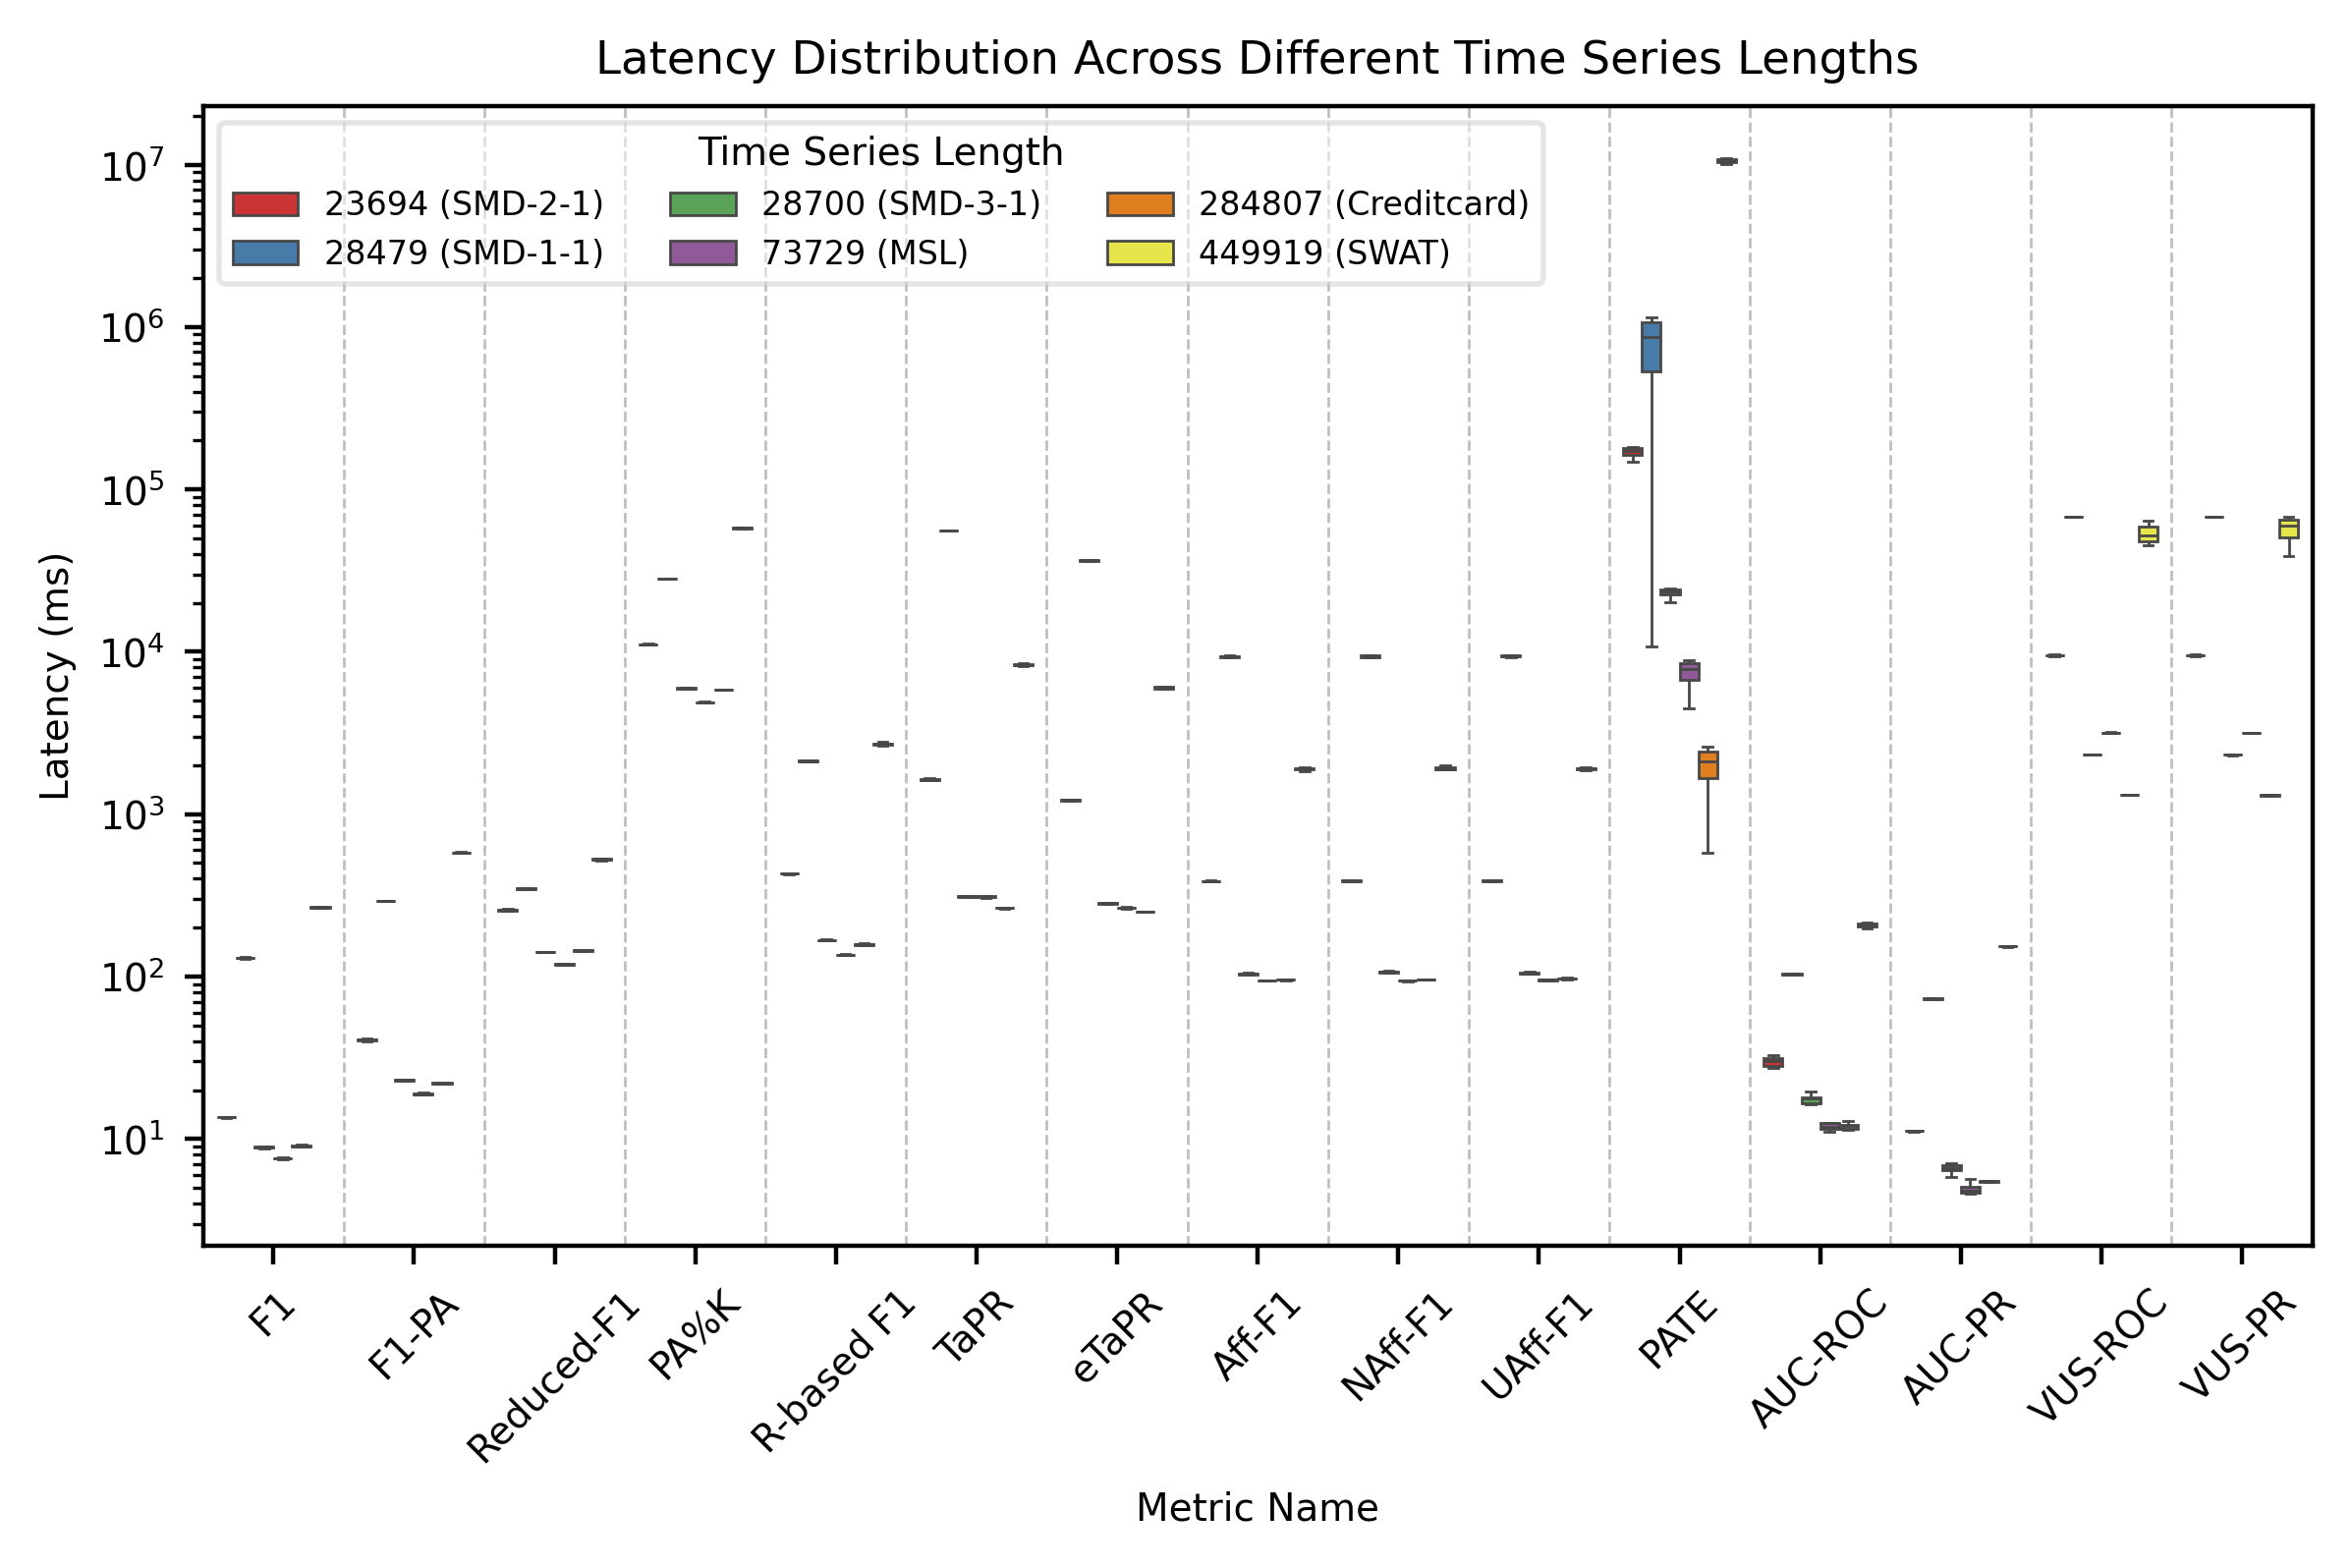

In [5]:
def plot_latency_distribution2(data_new, ver=1):
    df = data_new.copy()

    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    seg_list = df['seg'].unique()
    seg_type = df['seg_type'].unique()
    seg_avg_len = df['avg_seg_len'].unique()
    data_name = df['case_name'].unique()
    ts_len = df['ts_len'].unique()

    order_list = []
    if ver==1:
        out_name ='seg_latency_real'
        for data_n, seg in zip(data_name, seg_list):
            order_list.append((seg, f'{seg} Segs ({data_n})'))
    elif ver==2:
        out_name = 'len_latency_real'
        for data_n, ts_len_ in zip(data_name, ts_len):
            # avg_len = round(avg_len, 2)
            order_list.append((ts_len_, f'{ts_len_} ({data_n})'))
            # order_list.append((avg_len, f'Seg Len: {avg_len:.2f} ({data_n})'))

    # print(seg_list, seg_type, data_name)
    order_list = sorted(order_list, key=lambda x: x[0])
    print(order_list)
    seg_list = [x[0] for x in order_list]
    print(seg_list)
    legend_list = [x[1] for x in order_list]

    if ver == 1:
        plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df, 
                    order=metric_sort, 
                    hue='seg', 
                    hue_order=seg_list,
                    showfliers=False,
                    linewidth=0.5,
                    palette='Set1') 
    elif ver == 2:
        plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df, 
                    order=metric_sort, 
                    hue='seg_type', 
                    # hue_order=seg_list,
                    showfliers=False,
                    linewidth=0.5,
                    palette='Set1') 
    
    # min_max_ratios = df.groupby(['metric_name', 'seg'])['mean_latency'].agg(['min', 'max']).reset_index()
    # min_max_ratios['ratio'] = min_max_ratios['max'] / min_max_ratios['min']
    # seg_list = df['seg'].unique()
    # seg_list = sorted(seg_list, key=lambda x: int(x))  # Sort 
    # 获取当前图例句柄和标签
    handles, labels = plot1_handle.get_legend_handles_labels()
    print(handles, labels)

    # 设置新的图例标签
    legend_title = 'Average Segment Length' if ver == 1 else 'Time Series Length'
    plot1_handle.legend(handles, legend_list, title=legend_title, fontsize=6, loc='upper left', title_fontsize=7, framealpha=0.5,
                        ncol=3)
    # 计算每个 seg 类别的位置
    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    # plt.legend(title='Dataset')
    # 翻译：不同异常片段长度下的延迟分布
    if ver==1:
        plt.title(f'Latency Distribution Across Different Anomalous Segment Lengths')
    elif ver==2:
        plt.title(f'Latency Distribution Across Different Time Series Lengths')
    plt.xlabel('Metric Name')
    plt.ylabel('Latency (ms)')
    plt.yscale('log', base=10)  # 设置y轴为对数坐标
    plt.xticks(rotation=45)
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/{out_name}.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution2(data_new)  # Plot for all segments
plot_latency_distribution2(data_new,ver=2)  # Plot for all segments


/tmp/ipykernel_3928929/3672871839.py:27: UserWarning: The palette list has more values (20) than needed (10), which may not be intended.
  plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df,


    metric_name model_name          mean           std
31           F1   Model100     73.013084    107.091755
32           F1    Model20     72.563376    106.341057
33           F1    Model30     72.606590    106.336826
34           F1    Model40     72.718782    106.256697
35           F1    Model50     77.227240    119.306249
..          ...        ...           ...           ...
122      VUS-PR    Model20  22037.623756  28673.482876
123      VUS-PR    Model30  21796.444052  28388.797418
124      VUS-PR    Model40  25374.811967  33122.643528
125      VUS-PR    Model50  24803.208978  32260.208956
126      VUS-PR    Model60  24788.073203  32228.307895

[150 rows x 4 columns]


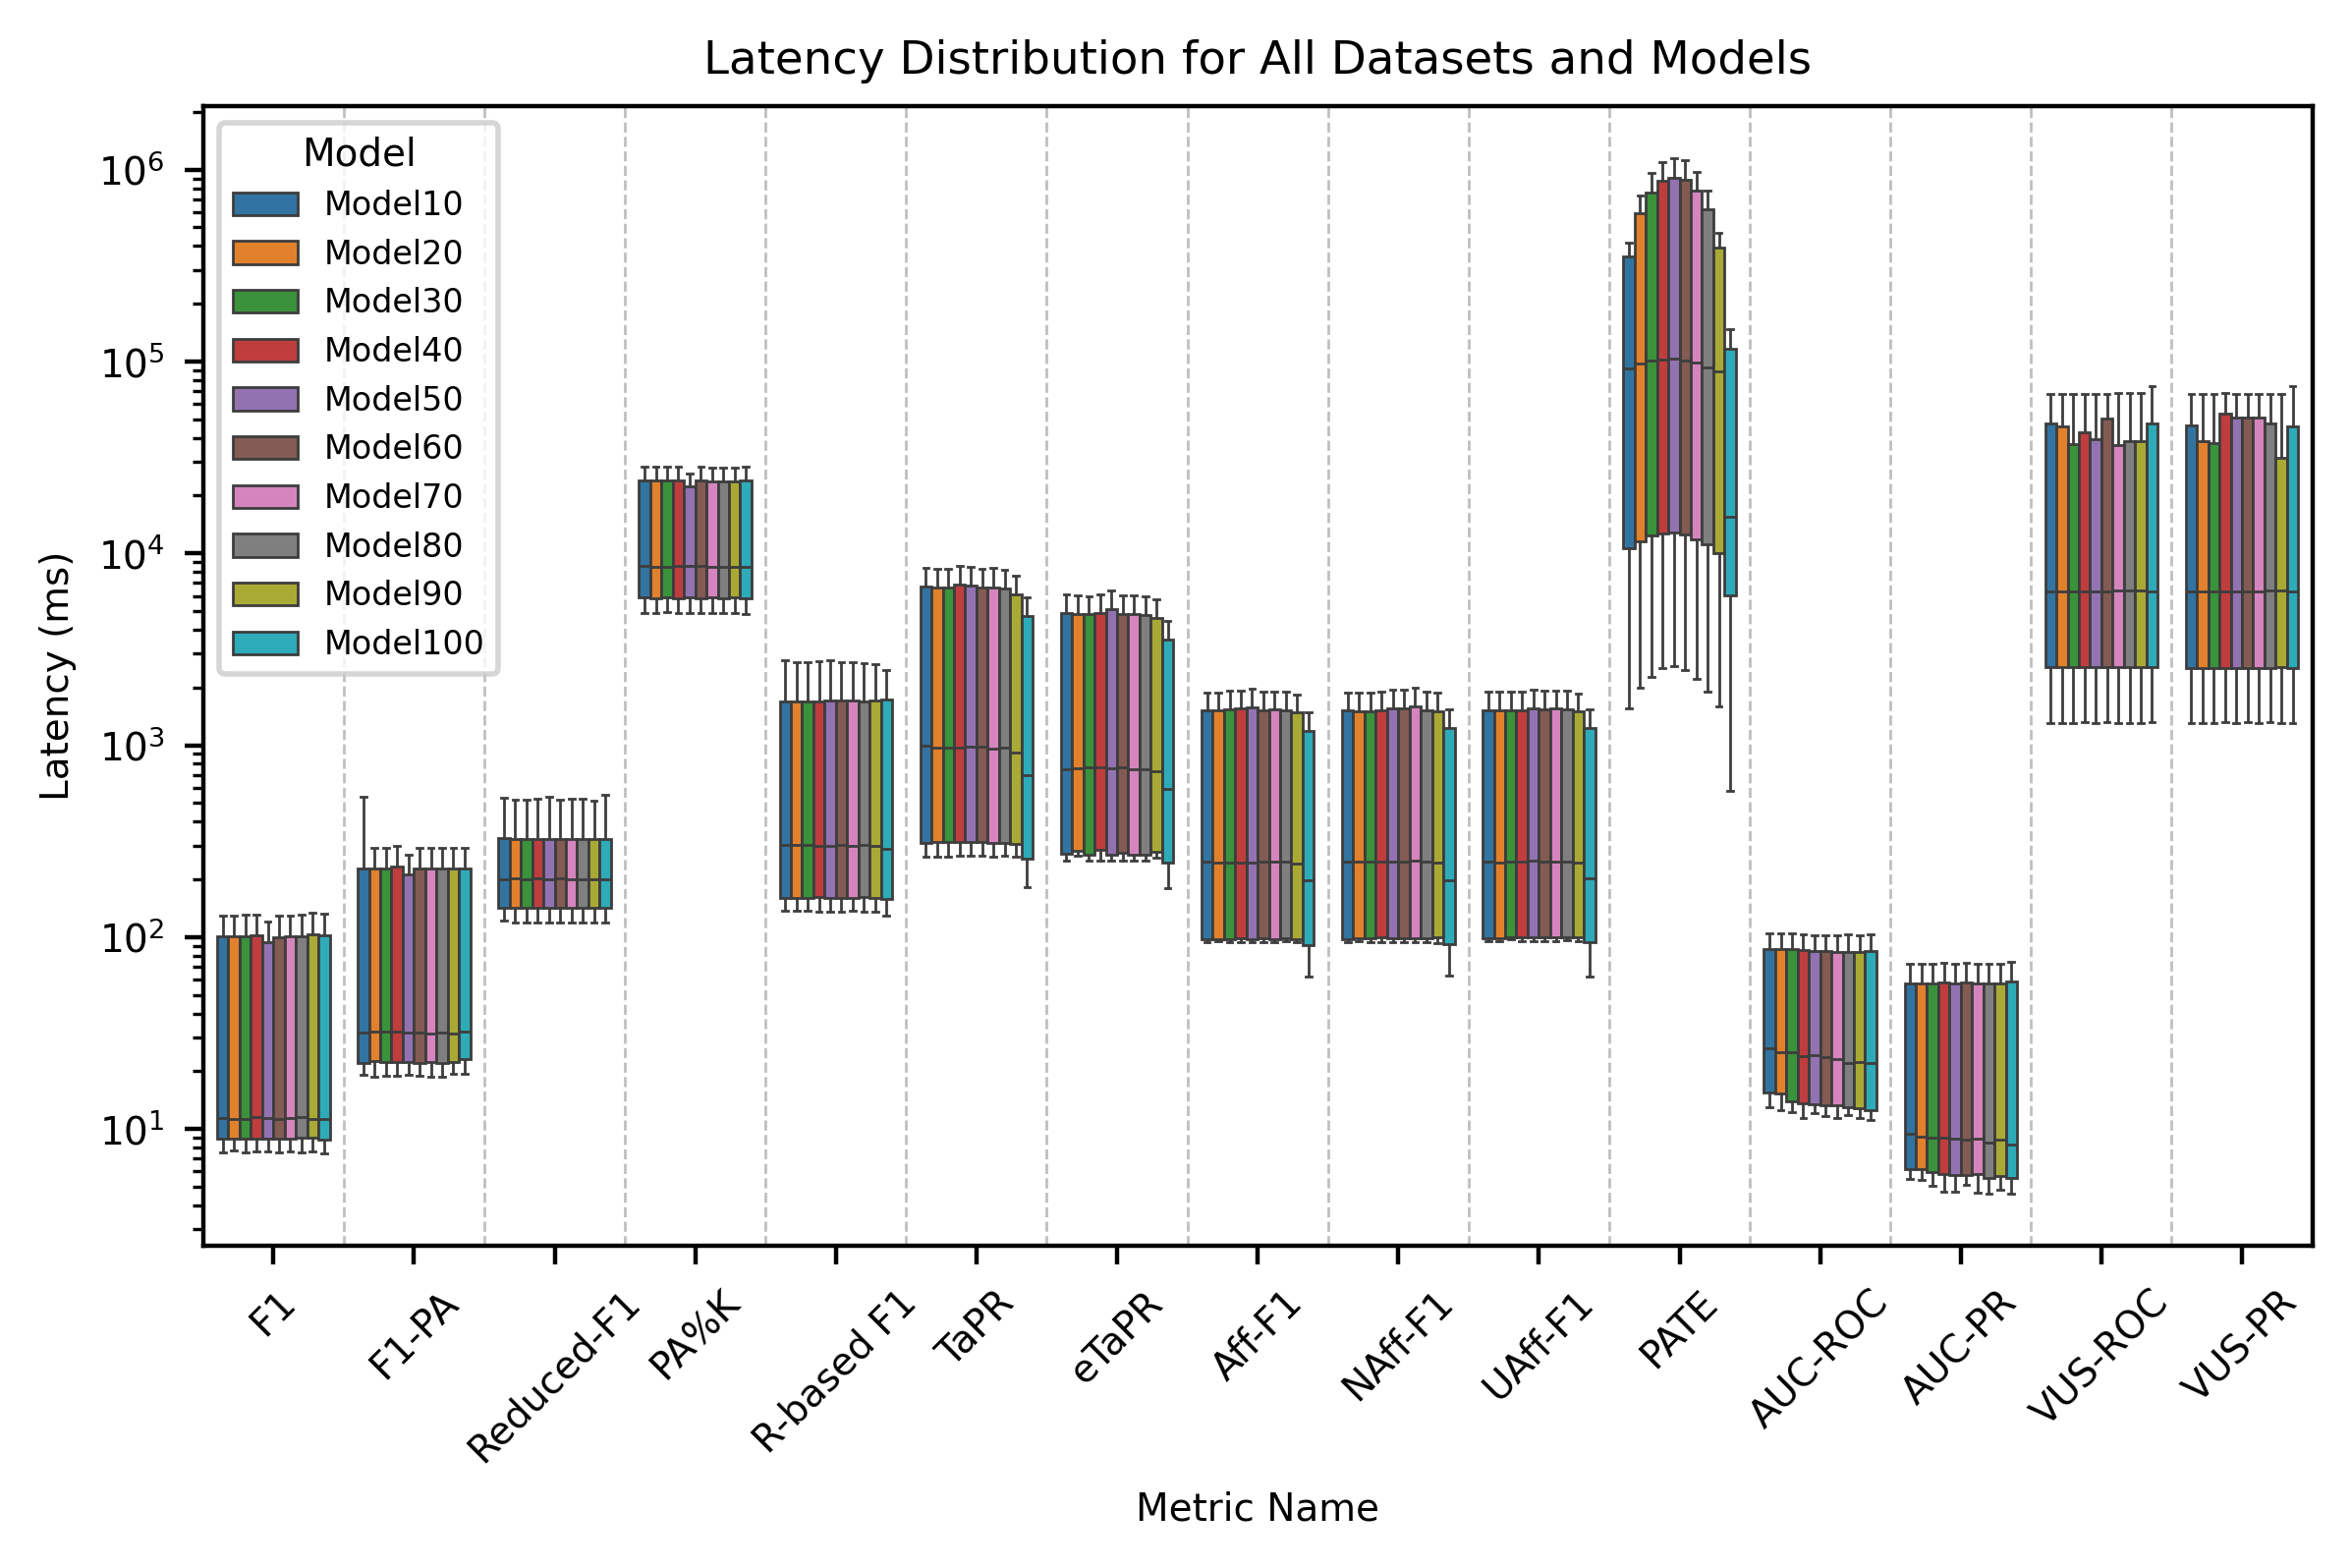

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_latency_distribution3(data_new):
    df = data_new.copy()

    # df = df[df['ts_len'] == ts_len]
    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    model_list = df['model_name'].unique()
    def sort_model_key_mdl(tmp):
        # 提取数字部分
        if tmp.startswith('Model'):
            num_part = tmp.split('Model')[-1]
            return int(num_part)
        else:
            return -float('inf')
        
    model_list = sorted(model_list, key=sort_model_key_mdl)
    # 定义一个包含足够多颜色的列表
    custom_palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", 
                  "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", 
                  "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", 
                  "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
    plot1_handle = sns.boxplot(x='metric_name', y='mean_latency', data=df, 
                order=metric_sort, 
                hue='model_name', 
                hue_order=model_list,
                showfliers=False,
                # 线粗
                linewidth=0.5,
                palette=custom_palette)
    diff_model = df.groupby(['metric_name', 'model_name'])['mean_latency'].agg(['mean', 'std']).reset_index()
    diff_model = diff_model.sort_values(by='metric_name', key=lambda x: x.apply(sort_metric_key))
    print(diff_model)    

    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

        
    plt.legend(title='Model', fontsize=6, loc='upper left', title_fontsize=7)
    # tmp = '100k' if ts_len == 100000 else f'{ts_len//1000}k'
    plt.title(f'Latency Distribution for All Datasets and Models')
    plt.xlabel('Metric Name')
    plt.ylabel('Latency (ms)')
    plt.yscale('log', base=10)  # 设置y轴为对数坐标
    plt.xticks(rotation=45)
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/model_latency_real.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution3(data_new)  # Plot for ts_len = 100000
# plot_latency_distribution3(data_new,10000)  # Plot for ts_len = 100000